# Introduction to Natural Language Processing (NLP)

## What is NLP?

Natural Language Processing (NLP) is a subfield of Artificial Intelligence (AI) that focuses on enabling computers to understand, interpret, and generate human language.  
It bridges the gap between **human communication** and **machine understanding**.

---

## Why Text Preprocessing?

Raw text is **unstructured** and contains many inconsistencies such as punctuation, mixed casing, stopwords, and irrelevant symbols.  
To make text understandable for models, we must **clean and normalize** it.

This step is called **Text Preprocessing**, and it helps:
- Reduce noise from raw text  
- Standardize data for analysis  
- Improve model accuracy and training efficiency  

---

## What is “Noise” in Text?

In NLP, **noise** refers to any content that does not add meaningful information for analysis or model learning.  
Examples include:
- HTML tags, URLs, and numbers  
- Punctuation marks and extra spaces  
- Stopwords (e.g., *the, is, are, and, to*)  
- Non-informative tokens like emojis or symbols  

Removing noise improves the **signal-to-noise ratio**, allowing models to focus on **meaningful linguistic patterns**.

---

## Core NLP Preprocessing Steps

| Step | Description | Purpose |
|------|--------------|----------|
| 1. **Text Cleaning** | Remove punctuation, numbers, special characters, and convert to lowercase | To make text uniform |
| 2. **Tokenization** | Split text into individual words or sentences | To prepare for analysis |
| 3. **Stopword Removal** | Remove frequent, unimportant words like “the”, “is”, “and” | To focus on meaningful words |
| 4. **Stemming** | Reduce words to root form (e.g., *running → run*) | To group related words together |
| 5. **Lemmatization** | Use vocabulary and grammar to get accurate base form (e.g., *better → good*) | More precise than stemming |
| 6. **Word Frequency Analysis** | Count how often each word appears | To identify common themes |
| 7. **Word Cloud Visualization** | Visualize most frequent words | To gain quick insight into dominant terms |

---

## Common Python Libraries Used in NLP

| Library | Primary Use | Example Tasks |
|----------|--------------|----------------|
| **nltk (Natural Language Toolkit)** | Foundation for classical NLP tasks | Tokenization, stemming, stopword removal, POS tagging |
| **re (Regular Expressions)** | Text cleaning and pattern matching | Removing numbers, punctuation, special symbols |
| **string** | Built-in string manipulation | Removing punctuation efficiently |
| **collections (Counter)** | Frequency counting | Word frequency and term analysis |
| **wordcloud** | Visualization of most frequent words | Creating word clouds |
| **matplotlib** | Plotting and visualization | Display word clouds or bar charts |

---

## Libraries That Perform Similar Tasks

Some libraries overlap in functionality:
- **NLTK** and **spaCy** both support tokenization, lemmatization, and POS tagging.  
  - NLTK → simpler and academic, suitable for learning.  
  - spaCy → faster and optimized for production.
- **Stemming** can be done via `nltk.PorterStemmer` or `SnowballStemmer`.
- **Stopword lists** exist in both `nltk.corpus.stopwords` and `spaCy`.

For beginners, **NLTK** is an excellent starting point due to its simplicity and wide support.

---

## Stemming vs. Lemmatization

| Aspect | Stemming | Lemmatization |
|---------|-----------|----------------|
| Method | Cuts off prefixes/suffixes | Uses a dictionary and grammar rules |
| Output | Often not a real word | Always a valid word |
| Example | *studies → studi* | *studies → study* |
| Accuracy | Faster, less accurate | Slower, more accurate |

**When to use:**
- Use **stemming** when speed matters and exact word form is not critical.  
- Use **lemmatization** when linguistic correctness is important.

---

## Summary

NLP preprocessing is the foundation of every text-based project.  
It involves cleaning raw data, normalizing words, removing irrelevant content, and preparing it for model training.  

**Goal:**  
Transform noisy, unstructured text into a clean, analyzable form suitable for tasks such as sentiment analysis, text classification, and translation.

---

**Next:** Run the following Python block to implement all preprocessing steps on a sample paragraph using NLTK and visualize the results.


In [19]:
#  Basic NLP Workflow in Python
#pip install "numpy<2" scipy==1.13.1 scikit-learn==1.5.0 --force-reinstall

# This script demonstrates core NLP preprocessing steps:
# 1. Cleaning text
# 2. Tokenization
# 3. Stopword removal
# 4. Stemming and Lemmatization
# 5. Frequency analysis
# 6. Word Cloud visualization


import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\arather\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arather\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arather\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
#  Create a sample text
text = """
Natural Language Processing (NLP) is a branch of Artificial Intelligence.
It helps computers understand, interpret, and respond to human language.
Applications include chatbots, translation, and sentiment analysis.
"""

print("Original Text:\n", text)

Original Text:
 
Natural Language Processing (NLP) is a branch of Artificial Intelligence.
It helps computers understand, interpret, and respond to human language.
Applications include chatbots, translation, and sentiment analysis.



In [21]:
#  Clean the text
def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r'\d+', '', text)                    # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()           # remove extra spaces
    return text

cleaned_text = clean_text(text)
print("\nCleaned Text:\n", cleaned_text)


Cleaned Text:
 natural language processing nlp is a branch of artificial intelligence it helps computers understand interpret and respond to human language applications include chatbots translation and sentiment analysis


In [22]:
# Tokenization
tokens = word_tokenize(cleaned_text)
print("\nTokens:\n", tokens)


Tokens:
 ['natural', 'language', 'processing', 'nlp', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'it', 'helps', 'computers', 'understand', 'interpret', 'and', 'respond', 'to', 'human', 'language', 'applications', 'include', 'chatbots', 'translation', 'and', 'sentiment', 'analysis']


In [23]:
#  Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
print("\nTokens after removing stopwords:\n", filtered_tokens)


Tokens after removing stopwords:
 ['natural', 'language', 'processing', 'nlp', 'branch', 'artificial', 'intelligence', 'helps', 'computers', 'understand', 'interpret', 'respond', 'human', 'language', 'applications', 'include', 'chatbots', 'translation', 'sentiment', 'analysis']


In [24]:
# Stemming
ps = PorterStemmer()
stemmed_tokens = [ps.stem(word) for word in filtered_tokens]
print("\nAfter Stemming:\n", stemmed_tokens)


After Stemming:
 ['natur', 'languag', 'process', 'nlp', 'branch', 'artifici', 'intellig', 'help', 'comput', 'understand', 'interpret', 'respond', 'human', 'languag', 'applic', 'includ', 'chatbot', 'translat', 'sentiment', 'analysi']


In [25]:

# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print("\nAfter Lemmatization:\n", lemmatized_tokens[:15])


After Lemmatization:
 ['natural', 'language', 'processing', 'nlp', 'branch', 'artificial', 'intelligence', 'help', 'computer', 'understand', 'interpret', 'respond', 'human', 'language', 'application']


In [26]:
# Word Frequency
word_freq = Counter(lemmatized_tokens)
print("\nMost Common Words:\n", word_freq.most_common(10))


Most Common Words:
 [('language', 2), ('natural', 1), ('processing', 1), ('nlp', 1), ('branch', 1), ('artificial', 1), ('intelligence', 1), ('help', 1), ('computer', 1), ('understand', 1)]


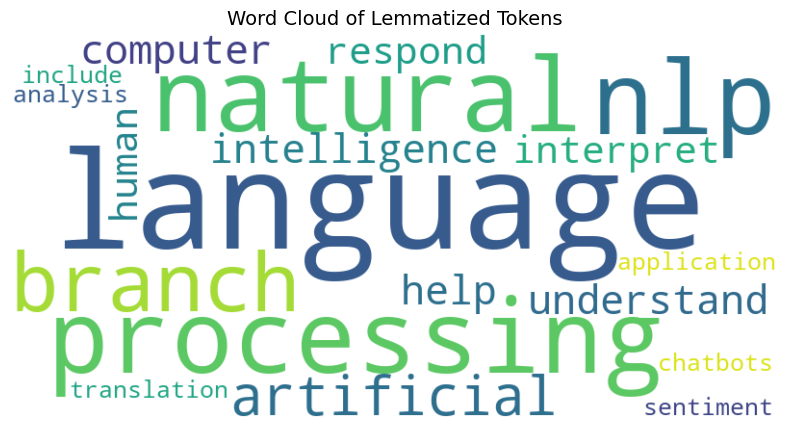

In [27]:
# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(lemmatized_tokens))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Lemmatized Tokens", fontsize=14)
plt.show()


## SpaCy

Original Text:
 
Natural Language Processing (NLP) is a branch of Artificial Intelligence.
It helps computers understand, interpret, and respond to human language.
Applications include chatbots, translation, and sentiment analysis.


Cleaned Text:
 natural language processing nlp is a branch of artificial intelligence it helps computers understand interpret and respond to human language applications include chatbots translation and sentiment analysis

Tokens after removing stopwords and lemmatizing:
 ['natural', 'language', 'processing', 'nlp', 'branch', 'artificial', 'intelligence', 'help', 'computer', 'understand', 'interpret', 'respond', 'human', 'language', 'application', 'include', 'chatbot', 'translation', 'sentiment', 'analysis']

Most Common Words:
 [('language', 2), ('natural', 1), ('processing', 1), ('nlp', 1), ('branch', 1), ('artificial', 1), ('intelligence', 1), ('help', 1), ('computer', 1), ('understand', 1)]


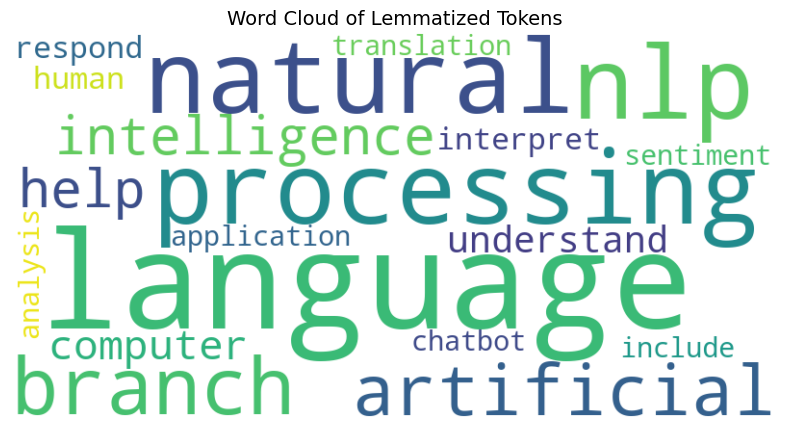

In [28]:
import spacy


# Load spaCy English model
# Make sure to run: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

# Sample text
text = """
Natural Language Processing (NLP) is a branch of Artificial Intelligence.
It helps computers understand, interpret, and respond to human language.
Applications include chatbots, translation, and sentiment analysis.
"""

print("Original Text:\n", text)

# Clean the text
def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r'\d+', '', text)                    # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()           # remove extra spaces
    return text

cleaned_text = clean_text(text)
print("\nCleaned Text:\n", cleaned_text)

# Process text with spaCy
doc = nlp(cleaned_text)

# Tokenization + Stopword removal + Lemmatization
tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
print("\nTokens after removing stopwords and lemmatizing:\n", tokens)

# Word Frequency
word_freq = Counter(tokens)
print("\nMost Common Words:\n", word_freq.most_common(10))

# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(tokens))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Lemmatized Tokens", fontsize=14)
plt.show()
